In [5]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
conn = sqlite3.connect("../database/ecommerce.db")
customers = pd.read_sql_query(
    "SELECT * FROM customers",
    conn
)
products = pd.read_sql_query(
    "SELECT * FROM Products",
    conn
)
orders = pd.read_csv("../data/Orders.csv")
payments = pd.read_csv("../data/Payments.csv")
merged = orders.merge(
    products,
    on="product_id"
)
merged["revenue"] = (
    merged["quantity"] *
    merged["price"]
)
merged["order_date"] = pd.to_datetime(
    merged["order_date"]
)
merged["month_name"] = (
    merged["order_date"]
    .dt.month_name()
)
merged["day_name"] = (
    merged["order_date"]
    .dt.day_name()
)

In [6]:
merged["order_date"] = pd.to_datetime(
    merged["order_date"],
    errors="coerce"
)

print("Missing dates:", merged["order_date"].isna().sum())

Missing dates: 0


In [7]:
monthly_revenue = (
    merged.dropna(subset=["order_date"])
    .set_index("order_date")
    .resample("MS")["revenue"]
    .sum()
)

monthly_revenue

order_date
2025-04-01    349868.0
Freq: MS, Name: revenue, dtype: float64

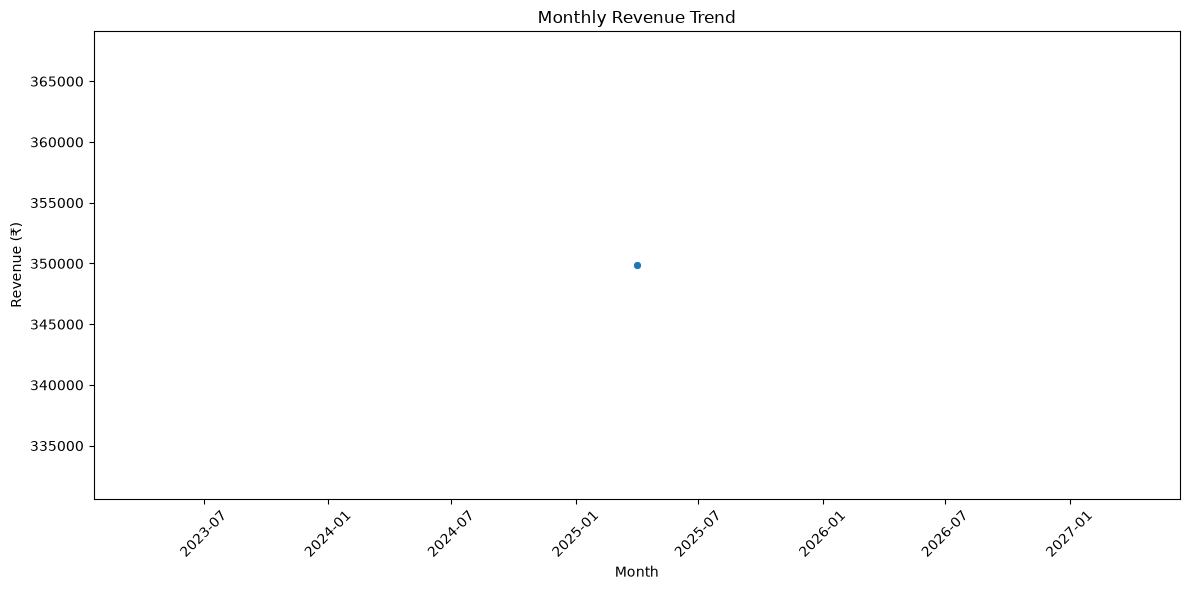

In [8]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values,
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
monthly_growth = monthly_revenue.pct_change() * 100

monthly_summary = pd.DataFrame({
    "revenue": monthly_revenue,
    "growth_percentage": monthly_growth
})

monthly_summary

,revenue,growth_percentage
order_date,,
2025-04-01,349868.0,NaN


In [10]:
monthly_growth = monthly_revenue.pct_change() * 100

monthly_summary = pd.DataFrame({
    "revenue": monthly_revenue,
    "growth_percentage": monthly_growth
})

monthly_summary

,revenue,growth_percentage
order_date,,
2025-04-01,349868.0,NaN
